# Transformações de Gráficos, Função Composta e Função Inversa

**Módulo:** 01 – Conjuntos e Funções (último notebook do módulo)

**Pré-requisitos:** [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano) e [`0106a_classificacao_e_operacoes_com_funcoes.ipynb`](0106a_classificacao_e_operacoes_com_funcoes.ipynb) (função par/ímpar, injetora/sobrejetora/bijetora, e a primeira introdução a função composta e função inversa)

**Objetivos de aprendizagem:**
- Prever como o gráfico de uma função muda ao aplicar translações, reflexões e dilatações/contrações verticais.
- Compor várias funções em cadeia e reconhecer que a ordem de composição importa.
- Encontrar a inversa de uma função composta, entendendo por que a ordem das funções se inverte.
- Relacionar transformações de gráfico, composição e inversão como formas de "combinar" ou "desfazer" funções.

**Tempo estimado:** 50 a 65 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/0112a_transformacoes_composta_e_inversa.ipynb)

## O jogo importado

Você decidiu comprar um jogo importado. O preço está em dólar, mas a loja brasileira faz três coisas em sequência antes de mostrar o valor final:

1. Converte o preço de dólar para real, usando a cotação do dia.
2. Soma o imposto de importação.
3. Aplica um cupom de desconto de valor fixo.

Cada etapa parte do resultado da etapa anterior — você não escolhe converter e aplicar o cupom "ao mesmo tempo", é sempre uma coisa depois da outra. E se um amigo te perguntar "quanto isso custava em dólar, antes de tudo isso?", dado só o preço final em real, como você desfaz o processo — e em que ordem?

Guarde essa pergunta. Antes de respondê-la, vamos entender três ideias que estão escondidas nela: como um gráfico se transforma quando você mexe numa função, como encadear funções (compor), e como desfazer esse encadeamento (inverter).

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## Transformações de gráficos

Antes de montar a cadeia do jogo importado, vamos ver algo mais simples: o que acontece com o **gráfico** de uma função quando você soma, subtrai ou multiplica alguma coisa nela (ou no x). Vamos usar f(x) = sen(x) como função-base ao longo de todo este bloco — ela tem uma forma reconhecível, então qualquer mudança fica fácil de enxergar.

### Translação vertical

- 📌 **Definição formal:** dado g(x) = f(x) + k, o gráfico de g é o gráfico de f **deslocado verticalmente** em k unidades — para cima se k > 0, para baixo se k < 0.
- A forma da curva não muda, só a posição no eixo y.

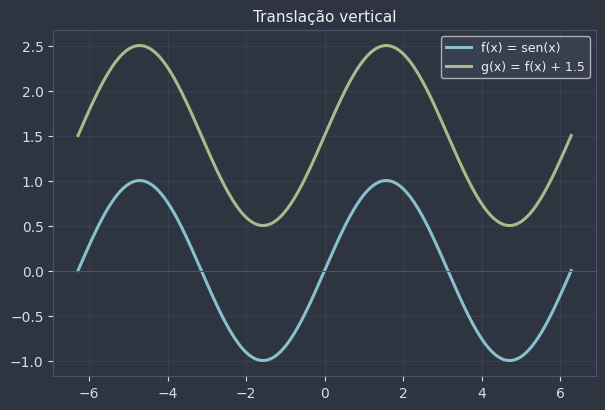

,x,f(x),g(x) = f(x) + 1.5
0,0.000000,0.000000e+00,1.5
1,1.570796,1.000000e+00,2.5
2,3.141593,1.224647e-16,1.5
3,4.712389,-1.000000e+00,0.5


In [2]:
xs = np.linspace(-2 * np.pi, 2 * np.pi, 400)


def f_base(x):
    return np.sin(x)


k_exemplo = 1.5
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs, f_base(xs), color=COR_PONTO, linewidth=2.2, label="f(x) = sen(x)")
ax.plot(xs, f_base(xs) + k_exemplo, color=COR_DESTAQUE, linewidth=2.2, label=f"g(x) = f(x) + {k_exemplo:g}")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
ax.set_title("Translação vertical", color=NORD_TEXTO, fontsize=11)
plt.show()

tabela_vertical = pd.DataFrame({
    "x": [0, np.pi / 2, np.pi, 3 * np.pi / 2],
    "f(x)": f_base([0, np.pi / 2, np.pi, 3 * np.pi / 2]),
    "g(x) = f(x) + 1.5": f_base([0, np.pi / 2, np.pi, 3 * np.pi / 2]) + k_exemplo,
})
tabela_vertical

### Translação horizontal

- 📌 **Definição formal:** dado g(x) = f(x − a), o gráfico de g é o gráfico de f **deslocado horizontalmente** em a unidades — para a **direita** se a > 0, para a **esquerda** se a < 0.
- ⚠️ **Erro comum:** o sinal aqui é contraintuitivo. f(x − a) desloca para a **direita** quando a > 0 (parece que devia ser o contrário). Pense assim: para g(a) valer o mesmo que f(0), você precisa de x = a — o gráfico "chega atrasado" em a unidades.

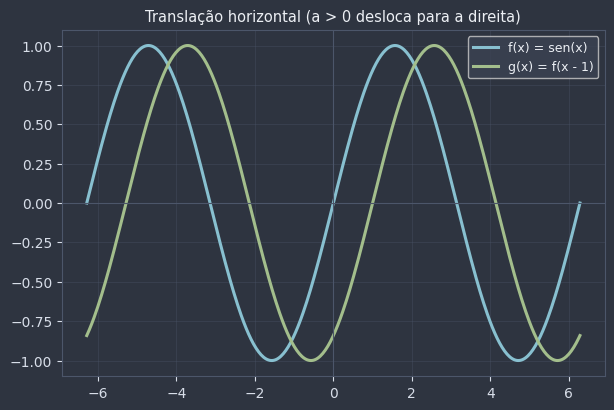

In [3]:
a_exemplo = 1.0
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs, f_base(xs), color=COR_PONTO, linewidth=2.2, label="f(x) = sen(x)")
ax.plot(xs, f_base(xs - a_exemplo), color=COR_DESTAQUE, linewidth=2.2, label=f"g(x) = f(x - {a_exemplo:g})")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
ax.set_title("Translação horizontal (a > 0 desloca para a direita)", color=NORD_TEXTO, fontsize=10.5)
plt.show()

**Pergunta de checagem:** se o gráfico de g(x) = f(x − a) aparece deslocado para a **esquerda** em relação a f, o valor de a é positivo ou negativo?

### Reflexões

- 📌 **Definição formal:** g(x) = −f(x) reflete o gráfico em torno do **eixo Ox** (espelha verticalmente). g(x) = f(−x) reflete o gráfico em torno do **eixo Oy** (espelha horizontalmente).

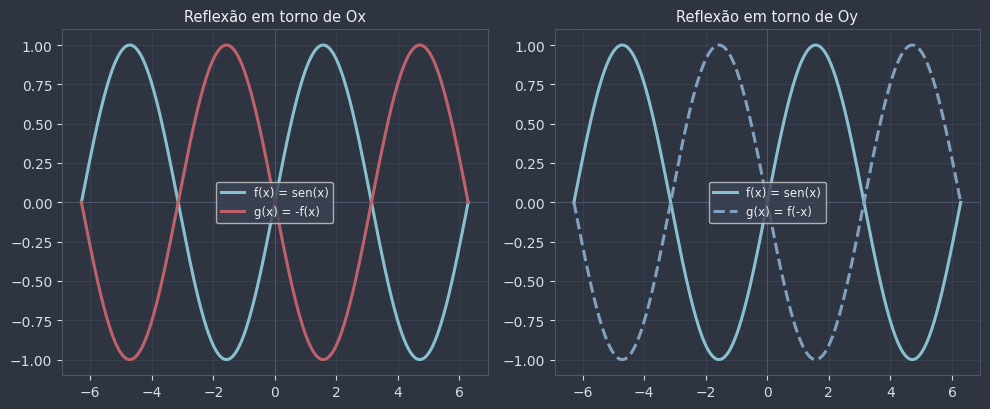

-f(x) e f(-x) são iguais para todo x? True


In [4]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 4.2))
fig.patch.set_facecolor(NORD_FUNDO)

for ax in eixos:
    estilizar_eixo(ax)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

eixos[0].plot(xs, f_base(xs), color=COR_PONTO, linewidth=2.2, label="f(x) = sen(x)")
eixos[0].plot(xs, -f_base(xs), color=COR_ALERTA, linewidth=2.2, label="g(x) = -f(x)")
eixos[0].set_title("Reflexão em torno de Ox", color=NORD_TEXTO, fontsize=10.5)
eixos[0].legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5)

eixos[1].plot(xs, f_base(xs), color=COR_PONTO, linewidth=2.2, label="f(x) = sen(x)")
eixos[1].plot(xs, f_base(-xs), color=COR_SECUNDARIA, linewidth=2.2, linestyle="--", label="g(x) = f(-x)")
eixos[1].set_title("Reflexão em torno de Oy", color=NORD_TEXTO, fontsize=10.5)
eixos[1].legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5)

plt.tight_layout()
plt.show()

print("-f(x) e f(-x) são iguais para todo x?", np.allclose(-f_base(xs), f_base(-xs)))

**Pergunta de checagem:** o código acima mostra que, para f(x) = sen(x), as curvas −f(x) e f(−x) coincidem. Isso não é coincidência — olhe de novo para a seção de função par e função ímpar em [`0106a_classificacao_e_operacoes_com_funcoes.ipynb`](0106a_classificacao_e_operacoes_com_funcoes.ipynb): qual propriedade de sen(x) garante que −f(x) = f(−x) para *qualquer* x? (Dica: é a mesma que define função ímpar.)

### Dilatação e contração vertical

- 📌 **Definição formal:** dado g(x) = c·f(x), o gráfico de g é o de f **esticado verticalmente** se |c| > 1, **comprimido** se 0 < |c| < 1. Se c < 0, a dilatação/contração vem acompanhada de uma reflexão em torno de Ox (caso do item anterior).
- 💡 **Dica:** no caso de f(x) = sen(x), |c| é exatamente a **amplitude** da onda — um jeito prático de já antecipar vocabulário que reaparece em [`05_trigonometria/`](../05_trigonometria/).

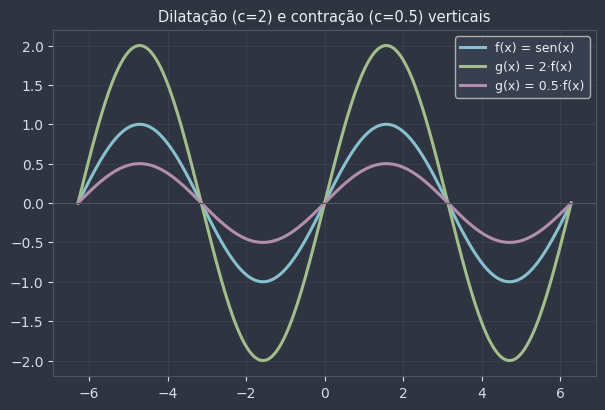

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs, f_base(xs), color=COR_PONTO, linewidth=2.2, label="f(x) = sen(x)")
ax.plot(xs, 2 * f_base(xs), color=COR_DESTAQUE, linewidth=2.2, label="g(x) = 2·f(x)")
ax.plot(xs, 0.5 * f_base(xs), color=COR_EXTRA, linewidth=2.2, label="g(x) = 0.5·f(x)")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
ax.set_title("Dilatação (c=2) e contração (c=0.5) verticais", color=NORD_TEXTO, fontsize=10.5)
plt.show()

### Juntando tudo: g(x) = c·f(x − a) + k

🕹️ **Widget interativo:** mexa nos três sliders e observe as quatro transformações ao mesmo tempo — a (deslocamento horizontal), k (deslocamento vertical) e c (fator: dilata/contrai se |c|≠1, reflete em Ox se c for negativo).

In [ ]:
def explorar_transformacoes(a: float, k: float, c: float) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, f_base(xs), color=COR_PONTO, linewidth=1.8, alpha=0.6, label="f(x) = sen(x)")
    ax.plot(xs, c * f_base(xs - a) + k, color=COR_DESTAQUE, linewidth=2.4,
            label=f"g(x) = {c:.2f}·f(x - {a:.2f}) + {k:.2f}")
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_ylim(-4, 4)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9, loc="upper right")
    ax.set_title("g(x) = c·f(x - a) + k", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_transformacoes,
    a=widgets.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description="a:"),
    k=widgets.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description="k:"),
    c=widgets.FloatSlider(value=1.0, min=-2.5, max=2.5, step=0.1, description="c:"),
)

interactive(children=(FloatSlider(value=0.0, description='a:', max=3.0, min=-3.0), FloatSlider(value=0.0, desc…

<function __main__.explorar_transformacoes(a: float, k: float, c: float) -> None>

🕵️ **Curiosidade histórica:** a ideia de descrever transformações geométricas por meio de operações algébricas sobre coordenadas vem da **geometria analítica** de Descartes e Fermat, no século XVII — antes disso, "mover uma curva" era só um desenho, sem uma álgebra por trás que dissesse exatamente quanto e para onde.

**Aplicações práticas:** em física, o movimento harmônico simples de uma onda é descrito por y = A·sen(x − φ) + D, onde A é a amplitude (dilatação), φ é a fase (deslocamento horizontal) e D é o deslocamento de equilíbrio (deslocamento vertical) — exatamente os parâmetros c, a e k do widget acima. Em ciência de dados, normalizar uma coluna (subtrair a média, dividir pelo desvio padrão) nada mais é do que aplicar uma translação e uma contração/dilatação sobre os dados.

📎 **Conexão com o próximo bloco:** cada transformação que você viu é, na prática, uma **composição** de f com uma função simples. Por exemplo, a translação vertical g(x) = f(x) + k é o mesmo que definir soma_k(y) = y + k e escrever g(x) = soma_k(f(x)) — ou seja, g = soma_k ∘ f. Vamos formalizar essa ideia agora.

## Função composta

Você já viu a definição de função composta em [`0106a_classificacao_e_operacoes_com_funcoes.ipynb`](0106a_classificacao_e_operacoes_com_funcoes.ipynb): (f∘g)(x) = f(g(x)), a composição não é comutativa em geral (f∘g ≠ g∘f), e o domínio da composta depende do domínio das duas funções envolvidas. Aqui não vamos repetir essa base — vamos **confirmar a conexão do Bloco 1** e depois aplicar composição a um problema real com **três** funções encadeadas: exatamente o que acontece na compra do jogo importado do gancho.

In [7]:
def soma_k(y):
    return y + k_exemplo


composicao_bate = np.allclose(soma_k(f_base(xs)), f_base(xs) + k_exemplo)
print(f"soma_k(f(x)) é igual a f(x) + {k_exemplo:g} para todo x? {composicao_bate}")
print("Ou seja: a translação vertical do Bloco 1 é (soma_k ∘ f)(x). Transformação = composição com uma função simples.")

soma_k(f(x)) é igual a f(x) + 1.5 para todo x? True
Ou seja: a translação vertical do Bloco 1 é (soma_k ∘ f)(x). Transformação = composição com uma função simples.


### A cadeia do jogo importado

Voltando ao gancho: três funções, aplicadas em sequência sobre o preço em dólar d.

- **Converter para real:** converter(d) = d · cotação
- **Aplicar imposto:** imposto(r) = r · (1 + taxa)
- **Aplicar cupom de desconto (valor fixo):** desconto(r) = r − cupom

O preço final é a composta das três: preco_final(d) = desconto(imposto(converter(d))) = (desconto ∘ imposto ∘ converter)(d).

In [10]:
cotacao_dolar = 5.0     # R$ por dólar
taxa_imposto = 0.20     # 20% de imposto de importação
cupom_desconto = 20.0   # R$20 de desconto fixo (cupom)


def converter_para_reais(preco_dolar):
    return preco_dolar * cotacao_dolar


def aplicar_imposto(preco_reais):
    return preco_reais * (1 + taxa_imposto)


def aplicar_desconto(preco_reais):
    return preco_reais - cupom_desconto


def preco_final_em_reais(preco_dolar):
    '''Composta das três etapas: converter, depois imposto, depois desconto.'''
    return aplicar_desconto(aplicar_imposto(converter_para_reais(preco_dolar)))


d_exemplo = 60
etapa1 = converter_para_reais(d_exemplo)
etapa2 = aplicar_imposto(etapa1)
etapa3 = aplicar_desconto(etapa2)

print(f"dólar: {d_exemplo}")
print(f"-> depois de converter: R$ {etapa1:.2f}")
print(f"-> depois do imposto:   R$ {etapa2:.2f}")
print(f"-> depois do cupom:     R$ {etapa3:.2f}  (preço final)")
print(f"confere com preco_final_em_reais({d_exemplo}) = {preco_final_em_reais(d_exemplo):.2f}")

dólar: 60
-> depois de converter: R$ 300.00
-> depois do imposto:   R$ 360.00
-> depois do cupom:     R$ 340.00  (preço final)
confere com preco_final_em_reais(60) = 340.00


In [11]:
precos_dolar = np.arange(20, 121, 20)

tabela_cadeia = pd.DataFrame({
    "dolar": precos_dolar,
    "apos_converter": converter_para_reais(precos_dolar),
    "apos_imposto": aplicar_imposto(converter_para_reais(precos_dolar)),
    "preco_final": preco_final_em_reais(precos_dolar),
})
tabela_cadeia

,dolar,apos_converter,apos_imposto,preco_final
0,20,100.0,120.0,100.0
1,40,200.0,240.0,220.0
2,60,300.0,360.0,340.0
3,80,400.0,480.0,460.0
4,100,500.0,600.0,580.0
5,120,600.0,720.0,700.0


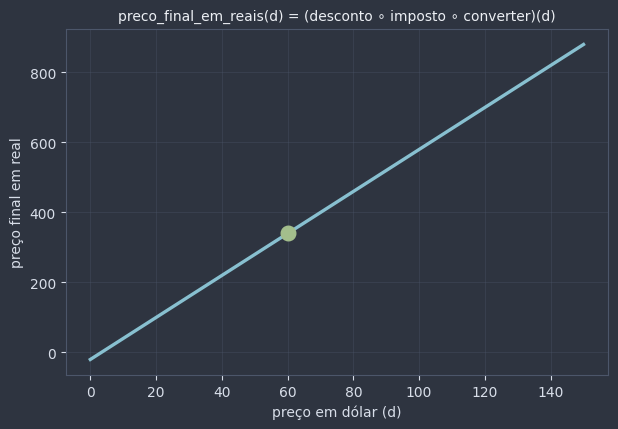

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
xs_dolar = np.linspace(0, 150, 200)
ax.plot(xs_dolar, preco_final_em_reais(xs_dolar), color=COR_PONTO, linewidth=2.4)
ax.scatter([d_exemplo], [preco_final_em_reais(d_exemplo)], s=110, color=COR_DESTAQUE, zorder=3)
ax.set_xlabel("preço em dólar (d)", color=NORD_TEXTO_SEC)
ax.set_ylabel("preço final em real", color=NORD_TEXTO_SEC)
ax.set_title("preco_final_em_reais(d) = (desconto ∘ imposto ∘ converter)(d)", color=NORD_TEXTO, fontsize=10)
plt.show()

### A ordem realmente importa aqui

⚠️ **Erro comum:** já que imposto e desconto parecem "só contas", dá pra pensar que a ordem não muda o resultado. Não é verdade quando o desconto é um valor **fixo** (em vez de percentual) — compare aplicar o cupom **antes** do imposto:

In [13]:
ordem_original = aplicar_imposto(converter_para_reais(d_exemplo))
ordem_original = aplicar_desconto(ordem_original)

ordem_trocada = aplicar_desconto(converter_para_reais(d_exemplo))
ordem_trocada = aplicar_imposto(ordem_trocada)

print(f"desconto depois do imposto (ordem da loja): R$ {ordem_original:.2f}")
print(f"desconto antes do imposto (ordem trocada):  R$ {ordem_trocada:.2f}")
print(f"resultados iguais? {math.isclose(ordem_original, ordem_trocada)}")

desconto depois do imposto (ordem da loja): R$ 340.00
desconto antes do imposto (ordem trocada):  R$ 336.00
resultados iguais? False


**Pergunta de checagem:** por que a ordem faz diferença aqui, mas não faria se o desconto também fosse percentual (por exemplo, "10% de desconto") em vez de um valor fixo de R$20?

## Bloco 3 — Função inversa

Em [`0106a_classificacao_e_operacoes_com_funcoes.ipynb`](0106a_classificacao_e_operacoes_com_funcoes.ipynb) você já viu que f⁻¹ só existe se f é bijetora, que f⁻¹(x) ≠ 1/f(x), que o gráfico de f⁻¹ é o de f refletido em torno de y = x, e como isolar a variável para achar a inversa algebricamente. Vamos aplicar tudo isso à pergunta do gancho: **dado o preço final em real, qual era o preço em dólar?**

### Desfazendo a cadeia

Para desfazer preco_final_em_reais = desconto ∘ imposto ∘ converter, cada etapa precisa da sua própria inversa — e elas entram na **ordem contrária**: desfaz-se o desconto primeiro (foi a última coisa aplicada), depois o imposto, depois a conversão.

- 💡 **Dica:** essa é uma regra geral, não só deste exemplo: **a inversa de uma composta inverte a ordem das funções**: (f∘g∘h)⁻¹ = h⁻¹∘g⁻¹∘f⁻¹. Faz sentido — se calçar a meia (h) e depois o sapato (f) é o processo, desfazer é tirar o sapato (f⁻¹) primeiro e a meia (h⁻¹) depois.

In [14]:
def desfazer_desconto(preco_reais):
    return preco_reais + cupom_desconto


def desfazer_imposto(preco_reais):
    return preco_reais / (1 + taxa_imposto)


def desfazer_conversao(preco_reais):
    return preco_reais / cotacao_dolar


def preco_original_em_dolar(preco_final_reais):
    '''Inversa da composta: desfaz desconto, depois imposto, depois conversão.'''
    return desfazer_conversao(desfazer_imposto(desfazer_desconto(preco_final_reais)))


preco_final_exemplo = preco_final_em_reais(d_exemplo)
dolar_recuperado = preco_original_em_dolar(preco_final_exemplo)

print(f"preço final em real: R$ {preco_final_exemplo:.2f}")
print(f"preço original recuperado: US$ {dolar_recuperado:.2f}  (era US$ {d_exemplo})")
print(f"preco_final_em_reais(preco_original_em_dolar(x)) == x ? "
      f"{math.isclose(preco_final_em_reais(dolar_recuperado), preco_final_exemplo)}")

preço final em real: R$ 340.00
preço original recuperado: US$ 60.00  (era US$ 60)
preco_final_em_reais(preco_original_em_dolar(x)) == x ? True


### f e f⁻¹ no mesmo plano

🕹️ **Widget interativo:** use o toggle para mostrar/esconder a reta y = x e a curva f⁻¹. Repare como preco_final_em_reais e preco_original_em_dolar são reflexo uma da outra em torno de y = x — a mesma relação gráfica que você já viu em 0106, agora com as funções do gancho.

In [15]:
def explorar_inversa_gancho(mostrar_inversa: bool, mostrar_y_igual_x: bool) -> None:
    xs_d = np.linspace(0, 150, 200)
    xs_r = preco_final_em_reais(xs_d)

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs_d, xs_r, color=COR_PONTO, linewidth=2.2, label="preco_final_em_reais(d)")
    if mostrar_inversa:
        ax.plot(xs_r, xs_d, color=COR_SECUNDARIA, linewidth=2.2, label="preco_original_em_dolar(r)")
    if mostrar_y_igual_x:
        limite = max(xs_d.max(), xs_r.max())
        ax.plot([0, limite], [0, limite], color=NORD_LINHA, linewidth=1.2, linestyle="--", label="y = x")
    ax.set_xlabel("entrada", color=NORD_TEXTO_SEC)
    ax.set_ylabel("saída", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9, loc="upper left")
    ax.set_title("f e f⁻¹ refletidas em torno de y = x", color=NORD_TEXTO, fontsize=10.5)
    plt.show()


widgets.interact(
    explorar_inversa_gancho,
    mostrar_inversa=widgets.ToggleButton(value=True, description="mostrar f⁻¹"),
    mostrar_y_igual_x=widgets.ToggleButton(value=True, description="mostrar y = x"),
)

interactive(children=(ToggleButton(value=True, description='mostrar f⁻¹'), ToggleButton(value=True, descriptio…

<function __main__.explorar_inversa_gancho(mostrar_inversa: bool, mostrar_y_igual_x: bool) -> None>

### Quando a inversa não existe

- ⚠️ **Lembrando de 0106:** f só tem inversa (como função) se for **bijetora**. Uma função não injetora falha porque, ao refletir o gráfico em y = x, dois pontos diferentes de f caem no mesmo x — e isso não é mais função.

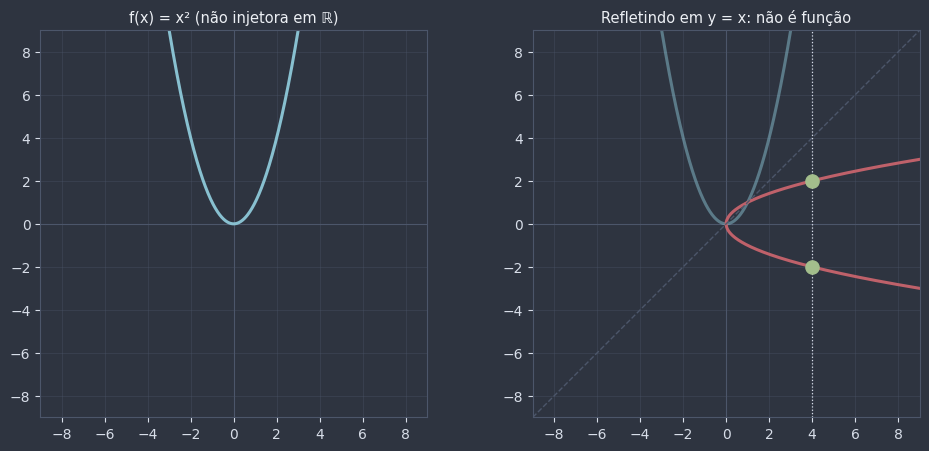

em x=4, o 'reflexo' de x² tem dois valores de y (2 e -2) -> não é o gráfico de uma função.


In [16]:
xs_quad = np.linspace(-3, 3, 300)

fig, eixos = plt.subplots(1, 2, figsize=(10, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)

eixos[0].set_title("f(x) = x² (não injetora em ℝ)", color=NORD_TEXTO, fontsize=10.5)
eixos[1].set_title("Refletindo em y = x: não é função", color=NORD_TEXTO, fontsize=10.5)

for ax in eixos:
    estilizar_eixo(ax)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-9, 9)
    ax.set_ylim(-9, 9)

eixos[0].plot(xs_quad, xs_quad ** 2, color=COR_PONTO, linewidth=2.2)
eixos[1].plot(xs_quad, xs_quad ** 2, color=COR_PONTO, linewidth=2.2, alpha=0.5)
eixos[1].plot(xs_quad ** 2, xs_quad, color=COR_ALERTA, linewidth=2.2)
eixos[1].plot([-9, 9], [-9, 9], color=NORD_LINHA, linewidth=1, linestyle="--")
eixos[1].axvline(4, color=NORD_TEXTO_SEC, linewidth=0.9, linestyle=":")
eixos[1].scatter([4, 4], [2, -2], s=90, color=COR_DESTAQUE, zorder=3)

plt.tight_layout()
plt.show()

print("em x=4, o 'reflexo' de x² tem dois valores de y (2 e -2) -> não é o gráfico de uma função.")

### A promessa do notebook anterior

Em [`0111a_outras_funcoes_elementares.ipynb`](0111a_outras_funcoes_elementares.ipynb) ficou combinado: "essa relação será formalizada quando função inversa for definida". Chegou a hora.

- f(x) = x² **não é bijetora em ℝ** (você acabou de ver o motivo). Mas, restringindo o domínio a x ≥ 0, ela vira bijetora — e nesse domínio restrito, f⁻¹(x) = √x.
- g(x) = x³ **já é bijetora em ℝ** (é sempre crescente). Sua inversa é g⁻¹(x) = ∛x.

In [17]:
def x_quadrado(x):
    return x ** 2


def x_cubo(x):
    return x ** 3


amostra = np.array([0, 1, 2.25, 4, 9])

print("x² (domínio x>=0) e depois √x devolve o valor original?",
      np.allclose(np.sqrt(x_quadrado(amostra)), amostra))
print("x³ e depois ∛x devolve o valor original?",
      np.allclose(np.cbrt(x_cubo(amostra)), amostra))

x² (domínio x>=0) e depois √x devolve o valor original? True
x³ e depois ∛x devolve o valor original? True


### Aplicações práticas

**Criptografia simples:** uma cifra de César desloca cada letra (representada por um número de 0 a 25) por uma quantidade fixa. Cifrar é f(x) = (x + deslocamento) mod 26; decifrar é a inversa, f⁻¹(x) = (x − deslocamento) mod 26 — a mesma ideia de "desfazer uma transformação" do Bloco 1, agora usada para embaralhar e desembaralhar uma mensagem.

In [18]:
deslocamento_cifra = 3


def cifrar(numero):
    return (numero + deslocamento_cifra) % 26


def decifrar(numero):
    return (numero - deslocamento_cifra) % 26


mensagem = [0, 4, 17, 24]  # A, E, R, Y (posição no alfabeto, A=0)
cifrada = [cifrar(n) for n in mensagem]
decifrada = [decifrar(n) for n in cifrada]

print("mensagem original:", mensagem)
print("mensagem cifrada: ", cifrada)
print("mensagem decifrada:", decifrada)
print("decifrar desfaz cifrar?", decifrada == mensagem)

mensagem original: [0, 4, 17, 24]
mensagem cifrada:  [3, 7, 20, 1]
mensagem decifrada: [0, 4, 17, 24]
decifrar desfaz cifrar? True


📌 **Olhando à frente:** a função inversa mais importante que vem por aí é o **logaritmo**, definido como a inversa da função exponencial — assunto do próximo módulo, [`02_logaritmos/`](../02_logaritmos/).

## Resumo — cheat sheet

**Transformações de f(x) para g(x):**

| g(x) | Efeito no gráfico |
|---|---|
| f(x) + k | translação vertical (cima se k>0, baixo se k<0) |
| f(x − a) | translação horizontal (direita se a>0, esquerda se a<0) |
| −f(x) | reflexão em torno do eixo Ox |
| f(−x) | reflexão em torno do eixo Oy |
| c·f(x) | dilatação se \|c\|>1, contração se 0<\|c\|<1, reflexão em Ox se c<0 |

**Função composta:** (f∘g)(x) = f(g(x)) — ordem importa, f∘g ≠ g∘f em geral. Uma cadeia com várias funções (f∘g∘h)(x) é só composição aplicada repetidas vezes, etapa por etapa.

**Função inversa:**
1. Escreva y = f(x).
2. Troque x por y e y por x.
3. Isole y — o resultado é f⁻¹(x).
4. Confirme com f(f⁻¹(x)) = x.

**Regra do espelho:** o gráfico de f⁻¹ é o gráfico de f refletido em torno da reta y = x.

**Regra da ordem invertida:** a inversa de uma composta desfaz as funções na ordem contrária — (f∘g∘h)⁻¹ = h⁻¹∘g⁻¹∘f⁻¹.

## Exercícios

**Básico**
1. Dado f(x) = x², escreva g(x) que representa "f deslocada 3 unidades para a direita e 2 para cima" e calcule g(5).
2. Dado f(x) = 2x + 1 e g(x) = x² − 3, calcule (g∘f)(2) e (f∘g)(2).

**Intermediário**
3. Encontre a inversa de f(x) = 3x + 4 e verifique que f(f⁻¹(10)) = 10.
4. Para f(x) = sen(x), determine g(x) = −2·f(x − 1) + 0.5 e calcule g(1) (use a função `math.sin`).

**Desafio**
5. Refaça a cadeia do jogo importado com uma nova cotação (cotacao_dolar = 5.5), mesma taxa de imposto (20%) e mesmo cupom (R$20), e calcule o preço final para d = 45.
6. Um amigo te diz que pagou R$ 250,00 pelo jogo (com a cotação original de 5.0, imposto de 20% e cupom de R$20). Descubra o preço original em dólar.

### Básico

In [ ]:
# Exercício Básico 1: g(x) representa f(x) = x^2 deslocada 3 unidades para a
# direita e 2 para cima. Escreva g_ex1 como uma função e calcule g_ex1(5).
def g_ex1(x):
    ...


valor_g5_ex1 = ...

print(valor_g5_ex1)

In [ ]:
# Verificação
assert math.isclose(g_ex1(5), 6), (
    "Tente de novo, revise o passo 1: deslocar 3 para a direita é "
    "trocar x por (x-3); deslocar 2 para cima é somar 2 no final."
)
assert valor_g5_ex1 == g_ex1(5), (
    "Tente de novo, revise o passo 1: valor_g5_ex1 deve ser g_ex1(5)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: f(x) = 2x+1, g(x) = x^2-3.
# Calcule (g∘f)(2) e (f∘g)(2).
def f_ex2(x):
    return 2 * x + 1


def g_ex2(x):
    return x ** 2 - 3


gf_2_ex2 = ...
fg_2_ex2 = ...

print(gf_2_ex2, fg_2_ex2)

In [ ]:
# Verificação
assert gf_2_ex2 == g_ex2(f_ex2(2)) == 22, (
    "Tente de novo, revise o passo 2: (g∘f)(2) = g(f(2)); primeiro calcule "
    "f(2), depois aplique g nesse resultado."
)
assert fg_2_ex2 == f_ex2(g_ex2(2)) == 3, (
    "Tente de novo, revise o passo 2: (f∘g)(2) = f(g(2)); primeiro calcule "
    "g(2), depois aplique f nesse resultado."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: encontre a inversa de f(x) = 3x+4 e verifique
# que f(f_inversa(10)) == 10.
def f_ex3(x):
    return 3 * x + 4


def f_inversa_ex3(x):
    ...


resultado_ex3 = ...

print(resultado_ex3)

In [ ]:
# Verificação
assert math.isclose(f_inversa_ex3(10), 2), (
    "Tente de novo, revise o passo 1: troque x por y e y por x em "
    "y = 3x+4, depois isole y. A inversa é f_inversa(x) = (x-4)/3."
)
assert math.isclose(resultado_ex3, 10), (
    "Tente de novo, revise o passo 1: resultado_ex3 deve ser "
    "f_ex3(f_inversa_ex3(10))."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: para f(x) = sen(x), calcule
# g(x) = -2*f(x-1) + 0.5 em x=1.
def g_ex4(x):
    ...


valor_g1_ex4 = ...

print(valor_g1_ex4)

In [ ]:
# Verificação
esperado_ex4 = -2 * math.sin(1 - 1) + 0.5
assert math.isclose(g_ex4(1), esperado_ex4), (
    "Tente de novo, revise o passo 4: g(x) = -2*sin(x-1) + 0.5, substitua "
    "x=1 (repare que sin(1-1) = sin(0) = 0)."
)
assert math.isclose(valor_g1_ex4, esperado_ex4), (
    "Tente de novo, revise o passo 4: valor_g1_ex4 deve ser g_ex4(1)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: refaça a cadeia do jogo importado com
# cotacao_dolar = 5.5, taxa_imposto = 0.20 e cupom_desconto = 20.0.
# Calcule o preço final (em real) para d = 45.
def preco_final_ex5(preco_dolar, cotacao, taxa, cupom):
    ...


preco_final_45_ex5 = ...

print(preco_final_45_ex5)

In [ ]:
# Verificação
esperado_ex5 = (45 * 5.5) * 1.20 - 20.0
assert math.isclose(preco_final_ex5(45, 5.5, 0.20, 20.0), esperado_ex5), (
    "Tente de novo, revise o passo 5: aplique, nesta ordem, "
    "converter -> imposto -> desconto: ((d*cotacao)*(1+taxa)) - cupom."
)
assert math.isclose(preco_final_45_ex5, esperado_ex5), (
    "Tente de novo, revise o passo 5: preco_final_45_ex5 deve ser o "
    "resultado de preco_final_ex5(45, 5.5, 0.20, 20.0)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: um amigo pagou R$250,00 pelo jogo, com a cotação
# original (5.0), imposto de 20% e cupom de R$20. Descubra o preço
# original em dólar (use as funções desfazer_* definidas no notebook).
dolar_original_ex6 = ...

print(dolar_original_ex6)

In [ ]:
# Verificação
esperado_ex6 = desfazer_conversao(desfazer_imposto(desfazer_desconto(250.0)))
assert math.isclose(dolar_original_ex6, esperado_ex6), (
    "Tente de novo, revise o passo 6: desfaça a cadeia na ordem "
    "contrária a que foi aplicada -- primeiro o cupom (some 20), "
    "depois o imposto (divida por 1.2), depois a conversão (divida "
    "pela cotação)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano)
- [`0106a_classificacao_e_operacoes_com_funcoes.ipynb`](0106a_classificacao_e_operacoes_com_funcoes.ipynb) (função par/ímpar, injetora/sobrejetora/bijetora, primeira introdução a composta e inversa)
- [`0111a_outras_funcoes_elementares.ipynb`](0111a_outras_funcoes_elementares.ipynb) (funções elementares usadas como exemplo em transformações e composição)

**Isso será usado em:**
- [`02_logaritmos/`](../02_logaritmos/) (logaritmo como função inversa da exponencial)
- [`05_trigonometria/`](../05_trigonometria/) (transformações de amplitude, período e fase em funções trigonométricas)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (a regra da cadeia depende diretamente de função composta)

---

Esse é o último notebook do módulo `01_conjuntos_e_funcoes`! Ele fecha o módulo amarrando três ideias — transformar, compor e inverter — que vão reaparecer, com nomes novos, em praticamente todos os módulos daqui pra frente.